# **Influencing Factors for Company Performance**

### **Authors:** Om Arvadia & Shreeyut Neupane  
### **Course / Context:** BIA 652  
### **Date:** December 1, 2025

---


##**Section 1: Problem Definition**

Research Question:
How accurately can key financial statement indicators- such as liquidity ratios, leverage ratios, cash flows, profitablity measures, and macroecomics facotrs. Predict a company's performance and outcomes (ROE, ROA, ROI, Net Profit, Market Cap, Revenue and Net Income) across multiple firms from 2009-2023.

Motivation and Signifcance:
Understanding which finanfical features most strongly drive company perforamce creates strategic value. it guides capital allocation, risk assessment and forecasing.This dataset spans 15 years of large multinational firms, providing a high-dimensional, multi-indsutry prespective. The motivation is to uncover which attrivutes matter most and whether multiuariate mdoels can distingush the strongest predictors.  

___

In [ ]:
#If missing installs remove comment on next line
#!pip install opendatasets pandas matplotlib scikit-learn kaggle

import os
import opendatasets as od
import pandas as pd
import seaborn as sns
from matplotlib import pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from IPython.display import display
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Ridge
from sklearn.pipeline import Pipeline
from sklearn.model_selection import GridSearchCV



# Dataset info
dataset_url = "https://www.kaggle.com/datasets/rish59/financial-statements-of-major-companies2009-2023"
folder_name = "financial-statements-of-major-companies2009-2023"

# Only download if the folder does NOT already exist
if not os.path.exists(folder_name):
    od.download(dataset_url)
else:
    print("Dataset already downloaded.")

# Load the CSV
csv_path = os.path.join(folder_name, "Financial Statements.csv")
df = pd.read_csv(csv_path)

# Print all column names (clean, one per line)
print("\nColumn Names:", df.columns)

Dataset already downloaded.

Column Names: Index(['Year', 'Company ', 'Category', 'Market Cap(in B USD)', 'Revenue',
       'Gross Profit', 'Net Income', 'Earning Per Share', 'EBITDA',
       'Share Holder Equity', 'Cash Flow from Operating',
       'Cash Flow from Investing', 'Cash Flow from Financial Activities',
       'Current Ratio', 'Debt/Equity Ratio', 'ROE', 'ROA', 'ROI',
       'Net Profit Margin', 'Free Cash Flow per Share',
       'Return on Tangible Equity', 'Number of Employees',
       'Inflation Rate(in US)'],
      dtype='object')


In [ ]:
# Cleans and standardizes column names
df.columns = df.columns.str.strip()
df["Year"] = pd.to_numeric(df["Year"], errors="coerce").astype("Int64")
df["Company"] = df["Company"].astype("string")
df["Category"] = df["Category"].astype("string")
df["Category_clean"] = df["Category"].str.strip().str.upper()

# Store unique values in variables as lists and drops missing values with dropna
year_list = sorted(df["Year"].dropna().unique().tolist())
company_list = sorted(df["Company"].dropna().unique().tolist())
category_list = sorted(df["Category"].dropna().unique().tolist())
category_clean_list = sorted(df["Category_clean"].dropna().unique().tolist())
print(
    "year_list =", year_list, "\n",
    "company_list =", company_list, "\n",
    "category_list =", category_list, "\n",
    "category_clean_list =", category_clean_list
)

year_list = [2009, 2010, 2011, 2012, 2013, 2014, 2015, 2016, 2017, 2018, 2019, 2020, 2021, 2022, 2023] 
 company_list = ['AAPL', 'AIG', 'AMZN', 'BCS', 'GOOG', 'INTC', 'MCD', 'MSFT', 'NVDA', 'PCG', 'PYPL', 'SHLDQ'] 
 category_list = ['BANK', 'Bank', 'ELEC', 'FOOD', 'FinTech', 'Finance', 'IT', 'LOGI', 'Manufacturing'] 
 category_clean_list = ['BANK', 'ELEC', 'FINANCE', 'FINTECH', 'FOOD', 'IT', 'LOGI', 'MANUFACTURING']


In [ ]:
# Standardizes Category by merge BANK and Bank to BANK since its same category and also just uppercase everything for easy retrieving and formating
df['Category'] = df['Category'].replace({'Bank': 'BANK'}).str.strip().str.upper()

# dictionary where ((key = industry)) and (((value = list of companies in that industry))
industry_companies = df.groupby("Category")["Company"].unique().apply(list).to_dict()
for industry, companies in industry_companies.items():
    print(f"{industry}: {list(companies)}")

BANK: ['AIG', 'BCS']
ELEC: ['NVDA', 'INTC']
FINANCE: ['SHLDQ']
FINTECH: ['PYPL']
FOOD: ['MCD']
IT: ['AAPL', 'MSFT', 'GOOG']
LOGI: ['AMZN']
MANUFACTURING: ['PCG']


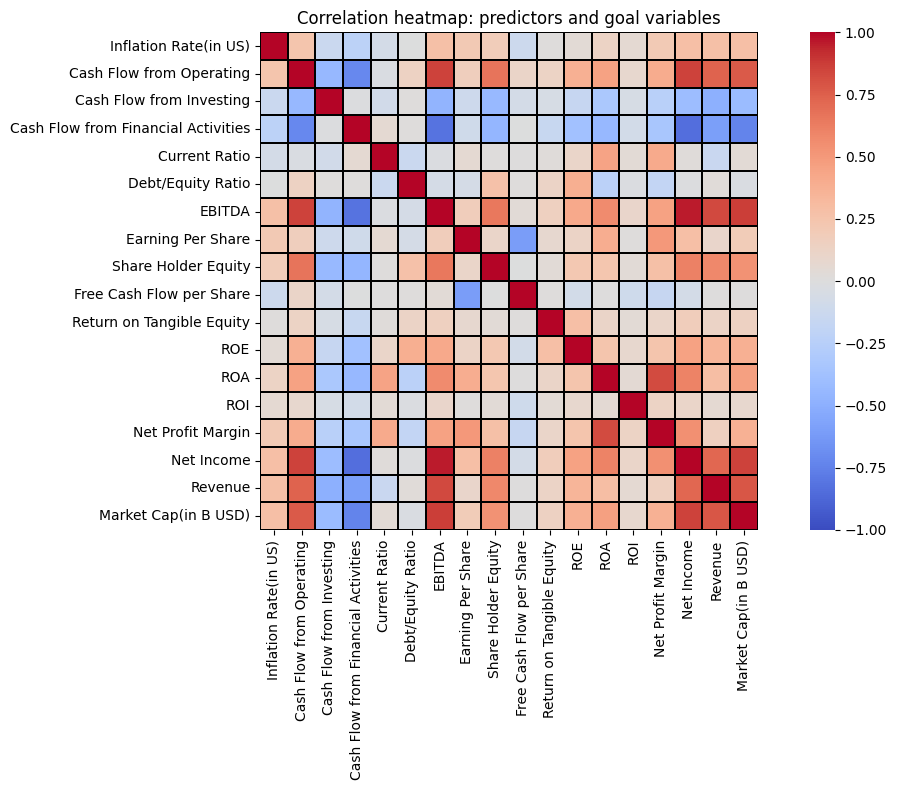

In [ ]:
predictor_cols = [
    "Inflation Rate(in US)",
    "Cash Flow from Operating",
    "Cash Flow from Investing",
    "Cash Flow from Financial Activities",
    "Current Ratio",
    "Debt/Equity Ratio",
    "EBITDA",
    "Earning Per Share",
    "Share Holder Equity",
    "Free Cash Flow per Share",
    "Return on Tangible Equity",
    #"Number of Employees" did not have any direct affect on the goals and in our findings was just harming the testing as a result
]

goals_cols = [
    "ROE",
    "ROA",
    "ROI",
    "Net Profit Margin",
    "Net Income",
    "Revenue",
    "Market Cap(in B USD)"
]

# This table will get filled with columns from predictor_cols that do best to predict each target column
best_predictors_for_goals = {
    "ROE": [],
    "ROA": [],
    "ROI": [],
    "Net Profit Margin": [],
    "Net Income": [],
    "Revenue": [],
    "Market Cap(in B USD)": []
}

identifier_cols = [
    "Year",
    "Company",
    "Category",
    "Category_clean"
]

corr_df = df[predictor_cols + goals_cols].select_dtypes(include=[np.number]).dropna()

# Full correlation matrix
corr_matrix = corr_df.corr()

# Heatmap 1: all pairwise correlations
plt.figure(figsize=(12, 8))
sns.heatmap(
    corr_matrix,
    cmap="coolwarm",
    center=0,
    vmin=-1, vmax=1,
    linewidths=0.3,
    linecolor="black",
    square=True
)
plt.title("Correlation heatmap: predictors and goal variables")
plt.tight_layout()
plt.show()

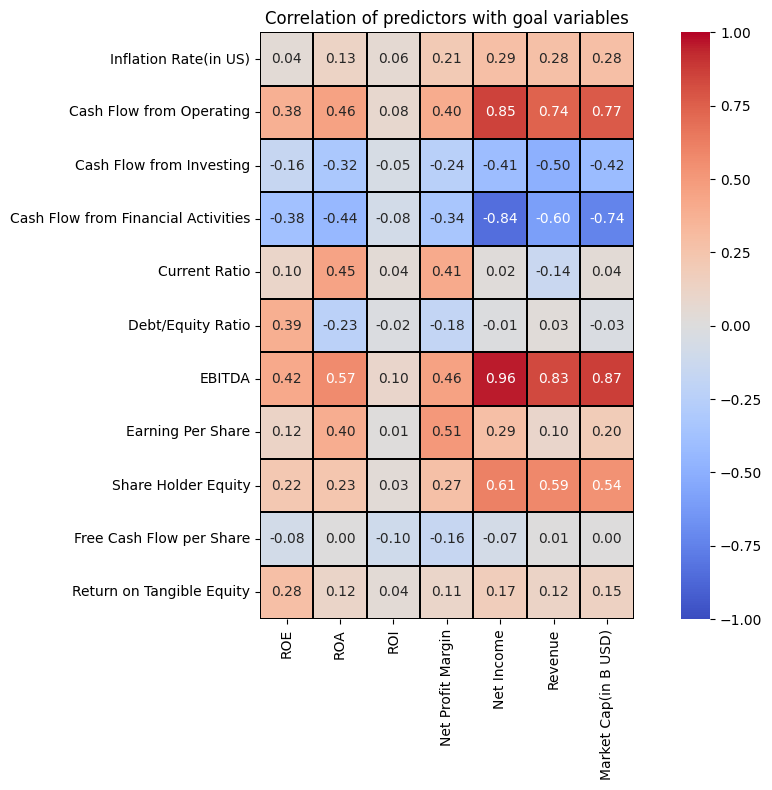

In [ ]:
# Heatmap 2: predictors (rows) vs goals (columns)
pred_vs_goal_corr = corr_matrix.loc[predictor_cols, goals_cols]

plt.figure(figsize=(10, 8))
sns.heatmap(
    pred_vs_goal_corr,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0,
    vmin=-1, vmax=1,
    linewidths=0.3,
    linecolor="black",
    square=True
)
plt.title("Correlation of predictors with goal variables")
plt.tight_layout()
plt.show()

# ***Correlation Analysis***
The correlation heatmap indicates that a small set of predictors are strongly associated with several of the financial goals, while others exhibit weaker or negative relationships. Measures of firm size and operating performance appear particularly influential for Net Income, Revenue, and Market Cap.

* EBITDA exhibits a very strong positive correlation with Net Income, Revenue, and Market Cap, indicating that firms with higher EBITDA tend to have significantly higher values for these outcomes.

* Cash Flow from Operating and Share Holder Equity also show strong positive relationships with Net Income, Revenue, and Market Cap, suggesting that robust operating cash generation and equity levels are closely linked to stronger financial performance.

* Cash Flow from Financial Activities and Cash Flow from Investing generally display negative correlations with the main financial goals, implying that higher outflows in these areas are associated with lower Net Income, Revenue, and Market Cap.

* All predictors demonstrate only weak correlations with ROI, indicating that variation in ROI is not strongly explained by any single predictor in the current set, and that ROI may be driven by more complex or unobserved factors beyond the included financial metrics.

# **Section 2: Data Analysis Task and Methodology**

### **Data Analysis Task**
The objective of this study is to determine how effectively financial statement variables can predict key corporate performance metrics. The analysis requires a combination of **estimation and predictive regression modeling**, along with **dimensionality reduction** and **unsupervised clustering** to explore structural patterns in the data.  
To address the research question, we implement:

- **Multiple Linear Regression** to quantify how strongly each predictor explains outcomes such as ROE, ROA, ROI, Net Profit Margin, Net Income, Revenue, and Market Cap.  
- **Principal Component Analysis (PCA)** to reduce dimensionality, identify latent financial factors, and evaluate the variance structure among predictors.  
- **K-Means Clustering** to uncover natural groupings of firms and compare financial profiles across performance tiers.

### **Multivariate Techniques and Justification**

1. **Regression Models (Multiple Linear Regression)**  
   Regression is used to estimate how well combinations of financial indicators predict each performance metric.  
   By running models with both **top predictors** and **all predictors**, we assess predictive power, stability, and the risk of overfitting.

2. **Principal Component Analysis (PCA)**  
   PCA reduces the original predictor set into a smaller number of orthogonal components that capture most of the variance.  
   This technique is appropriate because financial variables are often highly correlated (e.g., multiple earnings and cash-flow measures), and PCA helps reveal underlying financial dimensions such as profitability strength or leverage intensity.

3. **Cluster Analysis (K-Means)**  
   Clustering is applied to standardized predictor data and PCA-transformed scores to identify groups of firms with similar financial structures.  
   This method supports interpreting broader firm profiles, enabling comparisons between high-performing and underperforming clusters.

### **Model Assumptions and How They Were Addressed**

- **Linear Regression Assumptions:**  
  - *Linearity:* Verified through scatter patterns and performance of single-predictor relationships.  
  - *Multicollinearity:* Addressed using PCA to understand shared variance across predictors.  
  - *Scale comparability:* All numerical variables were standardized when required.  
  - *Generalizability:* Train/test splits and 5-fold cross-validation were used to monitor overfitting.

- **PCA Assumptions:**  
  - *Continuous numeric variables*: All predictors were coerced to numeric format.  
  - *High correlation structure:* PCA is justified because several financial measures are related (e.g., earnings, cash flows, leverage).  
  - *Mean-centered data:* StandardScaler was used prior to PCA.

- **Clustering (K-Means) Assumptions:**  
  - *Standardized features:* Required because K-Means is distance-based.  
  - *Roughly spherical clusters:* Evaluated using inertia and silhouette scores to identify a stable value of k (optimal k ≈ 3).  
  - *Dimensionality:* PCA scores were used to improve cluster separation and interpretability.

### **Feature Selection**
Feature selection was performed using a systematic, data-driven approach:

1. **Single-Predictor Screening:**  
   Each predictor was regressed individually against the target variable. Predictors producing the highest R² scores were identified.

2. **Top 5 Predictor Sets:**  
   For each performance metric (ROE, ROA, ROI, Net Profit Margin, Net Income, Revenue, Market Cap), the **five strongest predictors** were stored in the dictionary `best_predictors_for_goals`.

3. **Dimensionality Reduction via PCA:**  
   PCA identified a compact set of principal components explaining over **80% of the variance**, improving model efficiency and informing cluster analysis.

4. **Removal of Non-Informative Features:**  
   Variables such as *Number of Employees* were excluded when they consistently reduced model accuracy or contributed noise.

This combined strategy ensured that regression models avoided unnecessary predictors, and PCA/clustering were based on well-conditioned, relevant financial features.

___



## **Section 3: Data Description**
Dataset Source:
"Financial Statements of Major Companies (2009-2023)
Source: Kaggle (Rish59 dataset)
It contains annual financial statement information for major U.S. and global corporations over a 15-year period.  
Each row corresponds to a single `(Year, Company)` observation with associated financial and macroeconomic variables.

#### **Variables and Modeling Approach**

##### **Identifier Variables**
| Variable | Type | Description |
|---------|------|-------------|
| **Year** | Integer | Financial year (2009–2023) |
| **Company** | Categorical | Company ticker or name |
| **Category** | Categorical | Original sector/industry |
| **Category_clean** | Categorical | Cleaned/standardized category label |

##### **Predictor Variables**  
*(All modeled as continuous numeric features)*

| Variable | Description |
|---------|-------------|
| Inflation Rate (in US) | Macroeconomic annual inflation rate |
| Cash Flow from Operating | Operating cash flow |
| Cash Flow from Investing | Investing cash flow |
| Cash Flow from Financial Activities | Financing cash flow |
| Current Ratio | Liquidity ratio |
| Debt/Equity Ratio | Leverage measure |
| EBITDA | Operating earnings |
| Earning Per Share | EPS (profitability) |
| Share Holder Equity | Total equity value |
| Free Cash Flow per Share | Cash-flow profitability |
| Return on Tangible Equity | Tangible equity return |
| Number of Employees | Indicator of firm size |

##### **Target Variables**
| Variable | Description |
|---------|-------------|
| ROE | Return on Equity |
| ROA | Return on Assets |
| ROI | Return on Investment |
| Net Profit Margin | Profitability ratio |
| Net Income | Earnings after taxes |
| Revenue | Total annual revenue |
| Market Cap | Market valuation |


### **3.1 Preprocessing Steps**
The following preprocessing steps were performed before modeling:

1. **Column cleanup:**  
   Removed trailing/leading spaces and standardized column names.
2. **Data type correction:**  
   - Converted `Year` to integer  
   - Coerced all financial columns to numeric using `errors="coerce"`
3. **Category standardization:**  
   Created `Category_clean` by uppercasing and stripping `Category`.
4. **Handling missing values:**  
   - Numeric conversion introduced some NaNs  
   - Inspected missing counts per column  
   - Ensured no missing values in target variables before modeling
5. **Feature organization:**  
   - Predictor variables stored in `predictor_cols`  
   - Target variables organized for multi-output regression  
   - Identifier columns stored separately for grouping/analysis
6. **Initial exploratory checks:**  
   - Reviewed summary statistics (`df.describe()`)  
   - Checked for outliers and extreme magnitudes  
   - Verified distributions appropriate for PCA and regression

---

## **Section 4: Analysis and Results**

### **4.1 Linear Regression Modeling Framework**

To evaluate how well different financial features predict company performance, I
implemented a structured regression workflow that compares simple single-predictor
models with multivariate models containing multiple financial predictors.

#### **Model Testing Approach**

For each performance target (ROE, ROA, ROI, Net Profit Margin, Net Income, Revenue,
Market Cap), two multiple-regression models were built:

1. **Top-5 Predictor Model**  
   - Uses only the top five predictors identified from the single-predictor
     screening step.
   - Provides a compact, interpretable model.

2. **All-Predictors Model**  
   - Uses all financial predictors except *Number of Employees*, which was removed
     because it consistently reduced test accuracy and increased overfitting.
   - Represents the full information model.

To assess model performance, the data was split using a **70% training / 30% testing
split**, and three evaluation metrics were computed:

- **Training R²** – how well the model fits data it has seen  
- **Testing R²** – how well the model generalizes to unseen data  
- **5-fold Cross-Validation R²** – stability of the model across random splits

A well-fit model has:
- Training and testing scores within ~10% of each other  
- Positive and consistent cross-validation scores  

Large drops from training to testing accuracy indicate **overfitting**, whereas
negative testing R² indicates the model performs worse than simply predicting the
mean.

In [ ]:
# Dictionary where ((Key = Year)) and ((value = Inflation Rate for that year))
inflation_dict = {
    int(year): rate
    for year, rate in df.groupby("Year")["Inflation Rate(in US)"].first().items()
}

print(inflation_dict)

{2009: -0.3555, 2010: 1.64, 2011: 3.1568, 2012: 2.0693, 2013: 1.4648, 2014: 1.6222, 2015: 0.1186, 2016: 1.2616, 2017: 2.1301, 2018: 2.4426, 2019: 1.8122, 2020: 1.2336, 2021: 4.6979, 2022: 8.0028, 2023: 3.7}


In [ ]:
def scan_single_predictors(df, predictors, target_col, goal_name="Target"):
    """Compute single-predictor R² for each predictor. No plotting here."""
    results = []

    for year in sorted(df["Year"].dropna().unique()):
        year_df = df[df["Year"] == year]
        for pred in predictors:
            data = year_df[[pred, target_col]].dropna()
            if len(data) <= 2:
                continue

            X = data[[pred]]
            y = data[target_col]
            model = LinearRegression().fit(X, y)
            r2 = model.score(X, y)
            results.append({"Scope": f"Year {year}", "Predictor": pred, "R2": r2})

    # All years combined (single predictors)
    all_df = df[predictors + [target_col]].dropna()
    for pred in predictors:
        X = all_df[[pred]]
        y = all_df[target_col]
        model = LinearRegression().fit(X, y)
        r2 = model.score(X, y)
        results.append({"Scope": "All years", "Predictor": pred, "R2": r2})

    # Results DataFrame
    results_df = pd.DataFrame(results)
    all_years_df = results_df[results_df["Scope"] == "All years"].copy()
    all_years_df["R2"] = pd.to_numeric(all_years_df["R2"], errors="coerce")
    all_years_sorted = all_years_df.sort_values("R2", ascending=False)

    top5 = all_years_sorted["Predictor"].head(5).tolist()
    return results_df, all_years_sorted, top5


In [ ]:
def plot_predictor_r2(all_years_sorted, top5_test_r2, all_test_r2, goal_name):
    """
    Bar chart where single predictors, Top 5 model, and All predictors model
    are all included in one sorted list by R² (highest to lowest).
    """
    # Start from the single-predictor R² table
    plot_df = all_years_sorted[["Predictor", "R2"]].copy()
    plot_df["Type"] = "Single predictor"

    # Add rows for Top 5 model and All predictors model
    plot_df = pd.concat([
        plot_df,
        pd.DataFrame([
            {"Predictor": "Top 5 model", "R2": top5_test_r2, "Type": "Top 5 model"},
            {"Predictor": "All predictors", "R2": all_test_r2, "Type": "All predictors"},
        ])
    ], ignore_index=True)

    # Sort everything by R² descending
    plot_df = plot_df.sort_values("R2", ascending=False)

    # Choose colors by type
    color_map = {
        "Single predictor": "steelblue",
        "Top 5 model": "cyan",
        "All predictors": "green"
    }
    colors = plot_df["Type"].map(color_map).values

    # Plot
    plt.figure(figsize=(10, 5))
    x_pos = range(len(plot_df))
    plt.bar(x_pos, plot_df["R2"].values, color=colors)

    plt.xticks(x_pos, plot_df["Predictor"].values, rotation=90)
    plt.ylabel("R²")
    plt.title(f"How well each predictor and models explain {goal_name}")
    # Legend (manual handles)
    from matplotlib.patches import Patch
    handles = [
        Patch(color="steelblue", label="Single predictors"),
        Patch(color="cyan", label="Top 5 model (Test R²)"),
        Patch(color="green", label="All predictors model (Test R²)")
    ]
    plt.legend(handles=handles)
    plt.tight_layout()
    plt.show()


In [ ]:
def evaluate_predictor_sets(df, all_predictors, top_predictors, target_col, goal_name="Target"):
    from sklearn.model_selection import train_test_split, cross_val_score

    data = df[all_predictors + [target_col]].dropna()
    X = data[all_predictors]
    y = data[target_col]

    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.3, random_state=42
    )

    # Ridge pipeline: We set it so first it scales the date then uses ridge.
    ridge_pipe = Pipeline([
        ("scaler", StandardScaler()),
        ("model", Ridge())
    ])

    # Hyperparameter grid for alpha
    alpha_grid = {"model__alpha": [0.01, 0.1, 1.0, 10.0, 100.0]}

    # ---- TOP 5 predictors ----
    X_train_top5 = X_train[top_predictors]
    X_test_top5 = X_test[top_predictors]

    grid_top5 = GridSearchCV(ridge_pipe, alpha_grid, cv=5, scoring="r2")
    grid_top5.fit(X_train_top5, y_train)

    best_top5 = grid_top5.best_estimator_
    top5_train = best_top5.score(X_train_top5, y_train)
    top5_test = best_top5.score(X_test_top5, y_test)
    cv_top5 = grid_top5.best_score_

    # ---- ALL predictors ----
    grid_all = GridSearchCV(ridge_pipe, alpha_grid, cv=5, scoring="r2")
    grid_all.fit(X_train, y_train)

    best_all = grid_all.best_estimator_
    all_train = best_all.score(X_train, y_train)
    all_test = best_all.score(X_test, y_test)
    cv_all = grid_all.best_score_

    print(f"\n{goal_name} RESULTS (Ridge):")
    print(f"Top 5 Accuracy: Train={top5_train:.3f}  Test={top5_test:.3f}  CV={cv_top5:.3f}  Best alpha={grid_top5.best_params_['model__alpha']}")
    print(f"All Predictors Accuracy: Train={all_train:.3f}  Test={all_test:.3f}  CV={cv_all:.3f}  Best alpha={grid_all.best_params_['model__alpha']}")

    if abs(top5_train - top5_test) < 0.1:
        print("GOOD FIT")
    elif abs(top5_train - top5_test) < 0.15:
        print("SLIGHTLY OVERFITTING, difference isn't too much but train is performing between 10-15% better than test, so not in GOOD FIT range")
    else:
        print("OVERFITTING: Train much higher than Test")

    return (top5_train, top5_test, cv_top5), (all_train, all_test, cv_all)

In [ ]:
def analyze_goal(df, goal_name, target_col, predictor_cols, inflation_dict=None):
    if inflation_dict is not None:
        real_col = f"Real {goal_name}"
        df[real_col] = df[target_col] - df["Year"].map(inflation_dict)
        used_target = real_col
    else:
        used_target = target_col

    # 1) Single-predictor scan (no plot)
    results_df, all_years_sorted, top5 = scan_single_predictors(
        df, predictor_cols, used_target, goal_name=used_target
    )

    best_predictors_for_goals[goal_name] = top5
    print(f"Top 5 for {goal_name}: {top5}")

    # 2) Evaluate top5 vs all predictors
    (top5_train, top5_test, cv_top5), (all_train, all_test, cv_all) = evaluate_predictor_sets(
        df, predictor_cols, top5, used_target, goal_name=used_target
    )

    # 3) Plot single-predictor R² plus model R²s
    plot_predictor_r2(all_years_sorted, top5_test, all_test, used_target)

    return {
        "results_df": results_df,
        "sorted_all_years": all_years_sorted,
        "top5": top5,
        "r2_top_train": top5_train,
        "r2_top_test": top5_test,
        "r2_all_train": all_train,
        "r2_all_test": all_test,
        "target_used": used_target,
    }



ROE

Top 5 for ROE: ['EBITDA', 'Debt/Equity Ratio', 'Cash Flow from Financial Activities', 'Cash Flow from Operating', 'Return on Tangible Equity']

Real ROE RESULTS (Ridge):
Top 5 Accuracy: Train=0.305  Test=0.231  CV=0.285  Best alpha=100.0
All Predictors Accuracy: Train=0.348  Test=0.258  CV=0.232  Best alpha=100.0
GOOD FIT


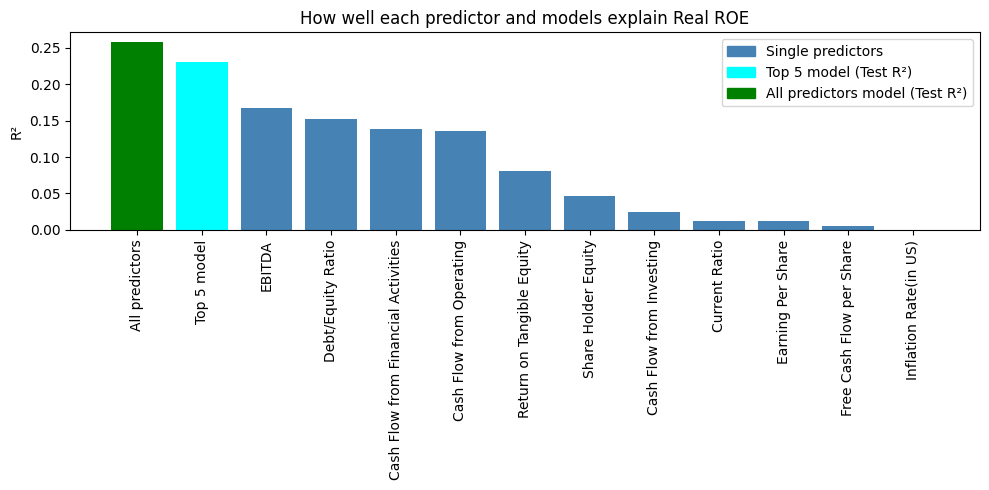

In [ ]:
#Print wasnt working well with each one together so using a different cell block for each response variable
print("\nROE\n")
summary_ROE = analyze_goal(df, "ROE", "ROE", predictor_cols, inflation_dict)



ROA

Top 5 for ROA: ['EBITDA', 'Cash Flow from Operating', 'Current Ratio', 'Cash Flow from Financial Activities', 'Earning Per Share']

ROA RESULTS (Ridge):
Top 5 Accuracy: Train=0.631  Test=0.518  CV=0.488  Best alpha=10.0
All Predictors Accuracy: Train=0.697  Test=0.581  CV=0.482  Best alpha=10.0
SLIGHTLY OVERFITTING, difference isn't too much but train is performing between 10-15% better than test, so not in GOOD FIT range


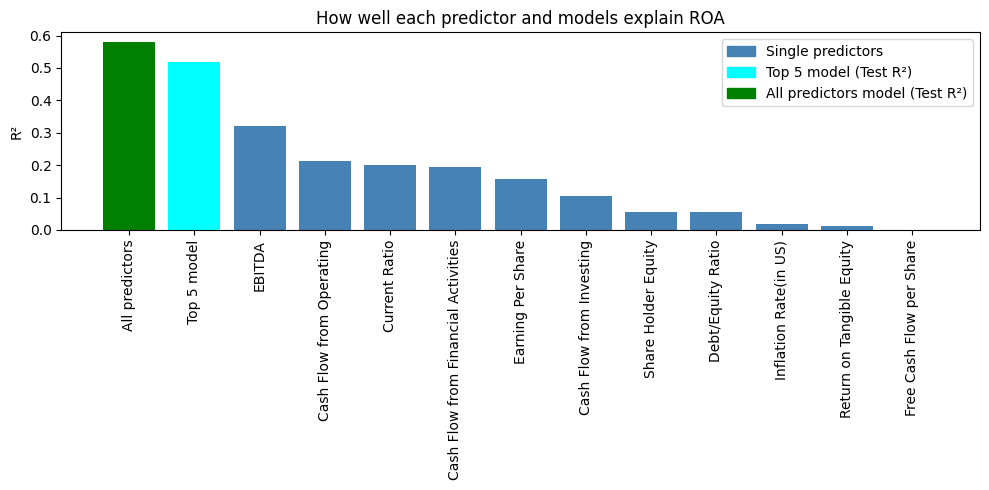

In [ ]:
print("\nROA\n")
summary_ROA = analyze_goal(df, "ROA", "ROA", predictor_cols, None)


ROI

Top 5 for ROI: ['Free Cash Flow per Share', 'EBITDA', 'Cash Flow from Operating', 'Cash Flow from Financial Activities', 'Inflation Rate(in US)']

ROI RESULTS (Ridge):
Top 5 Accuracy: Train=0.292  Test=0.003  CV=0.317  Best alpha=100.0
All Predictors Accuracy: Train=0.464  Test=-0.003  CV=0.335  Best alpha=100.0
OVERFITTING: Train much higher than Test


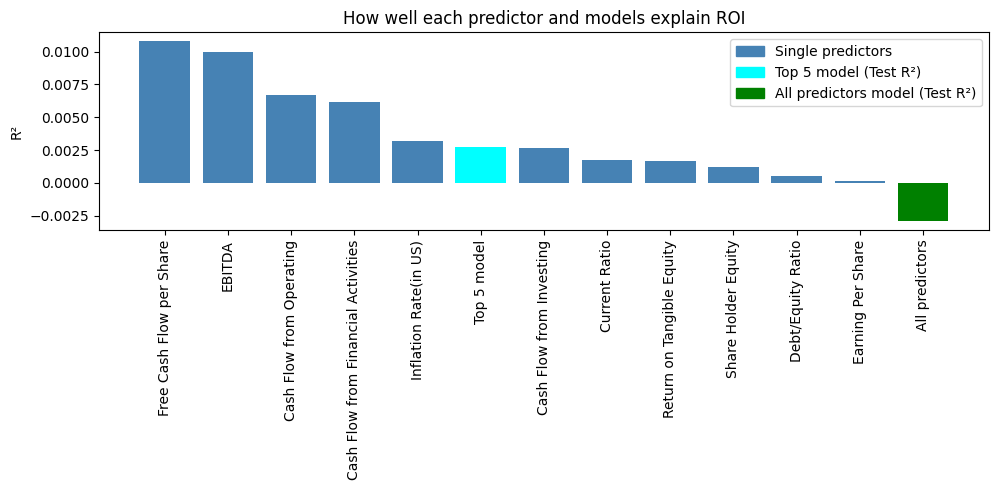

In [ ]:
print("\nROI\n")
summary_ROI = analyze_goal(df, "ROI", "ROI", predictor_cols, None)


Net Profit Margin

Top 5 for Net Profit Margin: ['Earning Per Share', 'EBITDA', 'Current Ratio', 'Cash Flow from Operating', 'Cash Flow from Financial Activities']

Net Profit Margin RESULTS (Ridge):
Top 5 Accuracy: Train=0.467  Test=0.401  CV=0.405  Best alpha=100.0
All Predictors Accuracy: Train=0.497  Test=0.400  CV=0.394  Best alpha=100.0
GOOD FIT


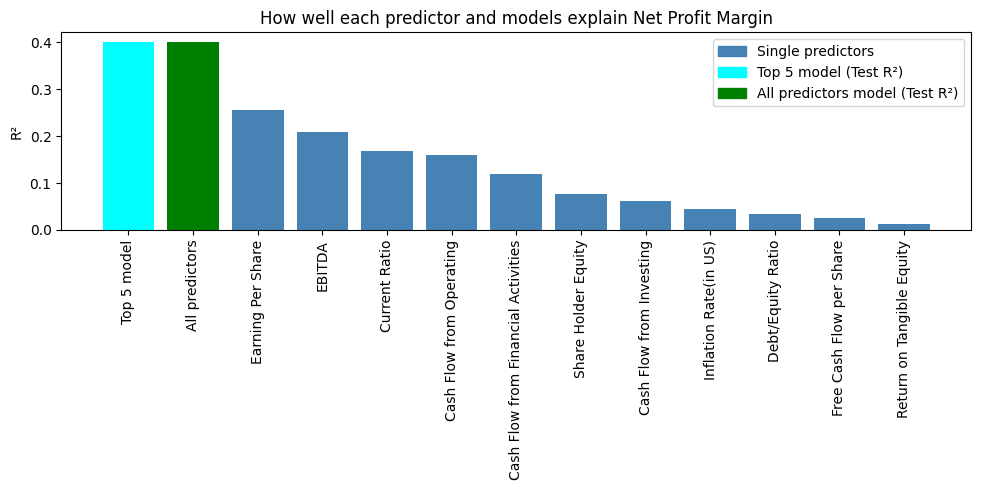

In [ ]:
print("\nNet Profit Margin\n")
summary_NPM = analyze_goal(df, "Net Profit Margin", "Net Profit Margin", predictor_cols, None)


Net Income

Top 5 for Net Income: ['EBITDA', 'Cash Flow from Operating', 'Cash Flow from Financial Activities', 'Share Holder Equity', 'Cash Flow from Investing']

Net Income RESULTS (Ridge):
Top 5 Accuracy: Train=0.911  Test=0.958  CV=0.869  Best alpha=10.0
All Predictors Accuracy: Train=0.943  Test=0.959  CV=0.868  Best alpha=10.0
GOOD FIT


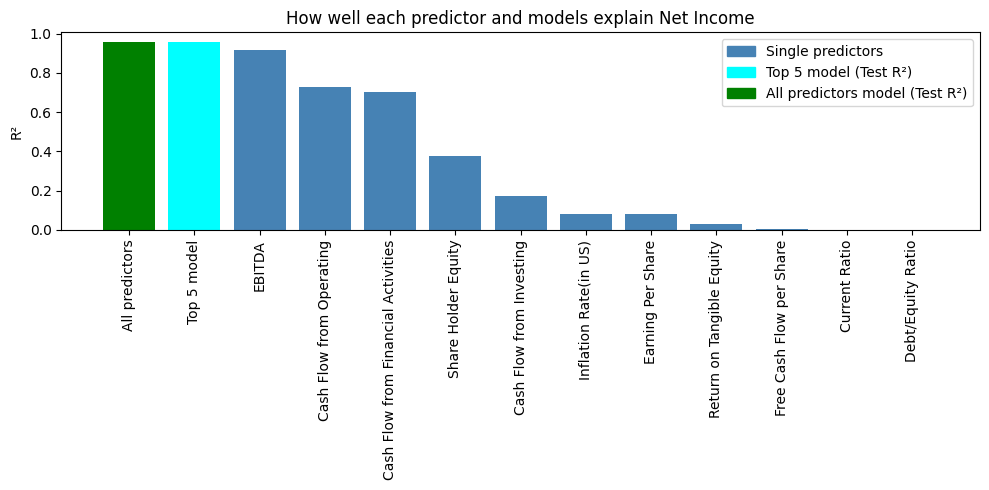

In [ ]:
print("\nNet Income\n")
summary_NI = analyze_goal(df, "Net Income", "Net Income", predictor_cols, None)


Revenue

Top 5 for Revenue: ['EBITDA', 'Cash Flow from Operating', 'Cash Flow from Financial Activities', 'Share Holder Equity', 'Cash Flow from Investing']

Revenue RESULTS (Ridge):
Top 5 Accuracy: Train=0.695  Test=0.687  CV=0.582  Best alpha=10.0
All Predictors Accuracy: Train=0.676  Test=0.659  CV=0.579  Best alpha=100.0
GOOD FIT


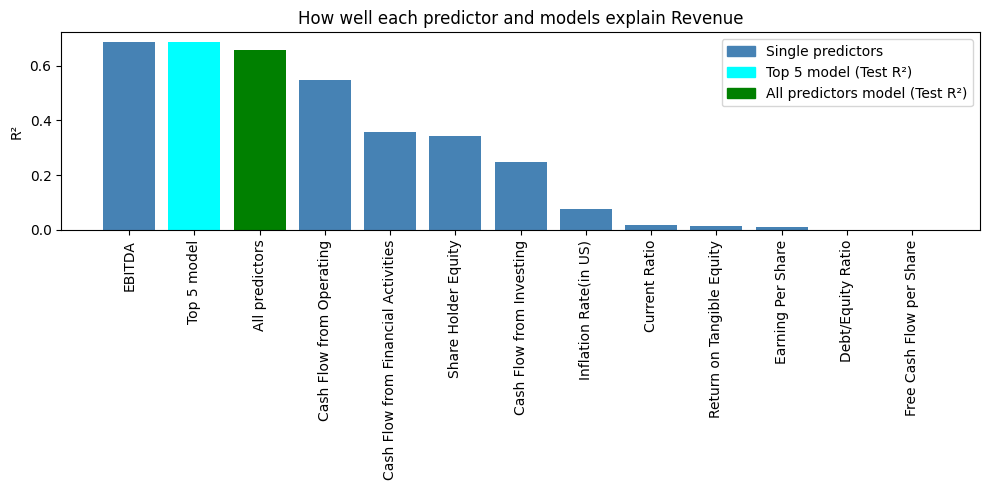

In [ ]:
print("\nRevenue\n")
summary_Revenue = analyze_goal(df, "Revenue", "Revenue", predictor_cols, None)


Market Cap(in B USD)

Top 5 for Market Cap(in B USD): ['EBITDA', 'Cash Flow from Operating', 'Cash Flow from Financial Activities', 'Share Holder Equity', 'Cash Flow from Investing']

Market Cap(in B USD) RESULTS (Ridge):
Top 5 Accuracy: Train=0.672  Test=0.677  CV=0.505  Best alpha=100.0
All Predictors Accuracy: Train=0.687  Test=0.677  CV=0.462  Best alpha=100.0
GOOD FIT


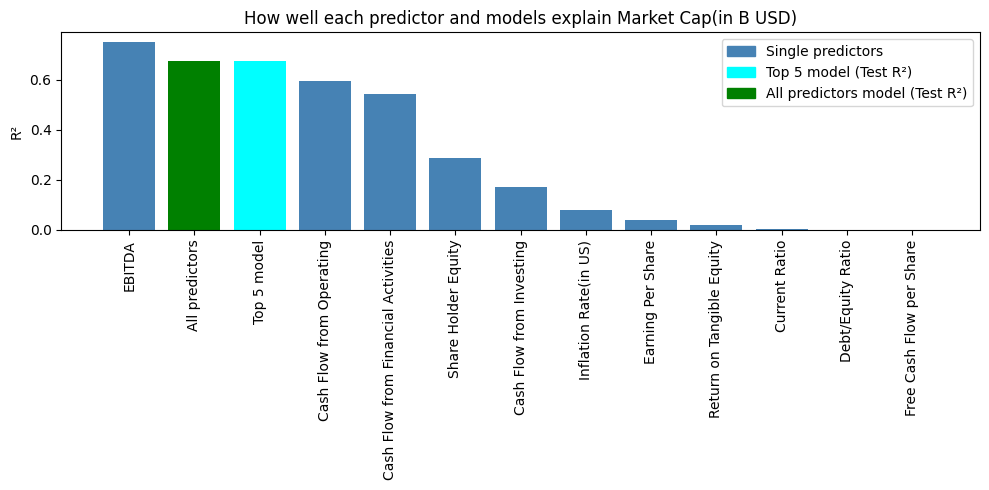

In [ ]:
print("\nMarket Cap(in B USD)\n")
summary_MarketCap = analyze_goal(df, "Market Cap(in B USD)", "Market Cap(in B USD)", predictor_cols, None)

In [ ]:
def incremental_models_for_roi(df, predictors_ranked, target_col="ROI"):
    """
    This function uses regularized linear regression using ridge same as before but now
    we have it set to build models with 1, 2, ..., k predictors and return train/test R².
    """
    cols = predictors_ranked + [target_col]
    data = df[cols].dropna()
    X_full = data[predictors_ranked]
    y = data[target_col]

    X_train, X_test, y_train, y_test = train_test_split(
        X_full, y, test_size=0.3, random_state=42
    )
    ridge_pipe = Pipeline([
        ("scaler", StandardScaler()),
        ("model", Ridge(alpha=100.0))
    ])

    results = []

    # Incrementally add best predictors: 1st best, 2nd best...
    for k in range(1, len(predictors_ranked) + 1):
        current_feats = predictors_ranked[:k]

        ridge_pipe.fit(X_train[current_feats], y_train)
        r2_train = ridge_pipe.score(X_train[current_feats], y_train)
        r2_test = ridge_pipe.score(X_test[current_feats], y_test)

        results.append({
            "k": k,
            "features": current_feats,
            "R2_train": r2_train,
            "R2_test": r2_test
        })

    return results

In [ ]:
results_roi, all_years_sorted_roi, _ = scan_single_predictors(
    df, predictor_cols, "ROI", goal_name="ROI"
)

# Predictors ordered by single-predictor R^2 from best to worst and then using the incremental function to store results
roi_predictors_ranked = all_years_sorted_roi["Predictor"].tolist()
print("Predictors ranked for ROI:", roi_predictors_ranked)
inc_results = incremental_models_for_roi(df, roi_predictors_ranked, target_col="ROI")

Predictors ranked for ROI: ['Free Cash Flow per Share', 'EBITDA', 'Cash Flow from Operating', 'Cash Flow from Financial Activities', 'Inflation Rate(in US)', 'Cash Flow from Investing', 'Current Ratio', 'Return on Tangible Equity', 'Share Holder Equity', 'Debt/Equity Ratio', 'Earning Per Share']


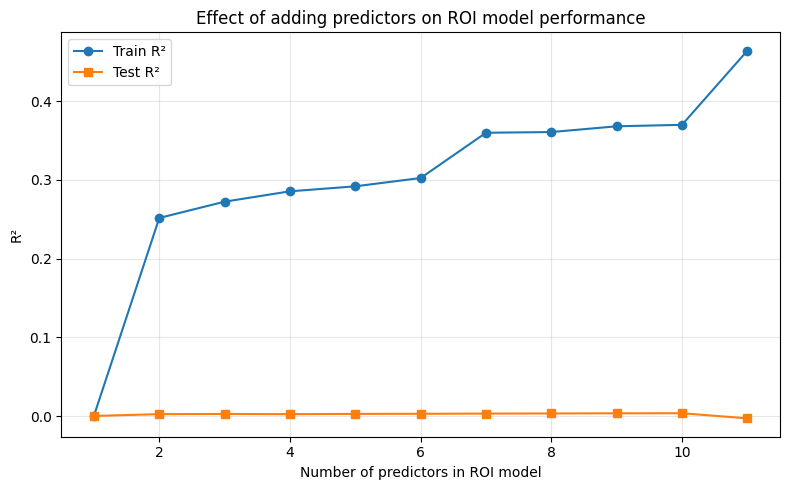

Best ROI model by Test R² uses 10 predictors.
Train R² = 0.370, Test R² = 0.004.
Predictors used in this model
 - Free Cash Flow per Share
 - EBITDA
 - Cash Flow from Operating
 - Cash Flow from Financial Activities
 - Inflation Rate(in US)
 - Cash Flow from Investing
 - Current Ratio
 - Return on Tangible Equity
 - Share Holder Equity
 - Debt/Equity Ratio


In [ ]:
k_vals = []
train_r2 = []
test_r2 = []

for r in inc_results:
    k_vals.append(r["k"])
    train_r2.append(r["R2_train"])
    test_r2.append(r["R2_test"])

plt.figure(figsize=(8, 5))
plt.plot(k_vals, train_r2, marker="o", label="Train R²")
plt.plot(k_vals, test_r2, marker="s", label="Test R²")
plt.xlabel("Number of predictors in ROI model")
plt.ylabel("R²")
plt.title("Effect of adding predictors on ROI model performance")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

best_entry = max(inc_results, key=lambda r: r["R2_test"])
best_k = best_entry["k"]
best_test_r2 = best_entry["R2_test"]
best_train_r2 = best_entry["R2_train"]
best_feats = best_entry["features"]

print(f"Best ROI model by Test R² uses {best_k} predictors.")
print(f"Train R² = {best_train_r2:.3f}, Test R² = {best_test_r2:.3f}.")
print("Predictors used in this model")
for f in best_feats:
    print(f" - {f}")

# ***ROI Summary***
The incremental ROI models show that test R² remains very close to zero regardless of how many predictors are added, even as train R² steadily increases with model size. This pattern, combined with the weak individual correlations between all predictors and ROI, indicates that the current financial variables provide little explanation for ROI and that adding more features mainly increases overfitting rather than improving predictive performance.

#### **Key Observations Across All Targets**

- Some metrics such as **Net Income**, **Revenue**, and **Market Cap** were predicted
  very accurately, with train, test, and cross-validation scores all closely
  aligned—showing strong, stable relationships in the data.

- For ratio-based metrics (ROE, ROA, Net Profit Margin), the models captured
  meaningful signal but showed varying degrees of overfitting and instability.

- **ROI** was the weakest target: both top-5 and full models performed poorly,
  often with negative testing R², indicating the available predictors do not
  explain ROI well.

#### **Feature Importance Patterns**

Across nearly all targets, the same predictors consistently appeared in the
best-performing models:

- **EBITDA** – strongest predictor overall; summarizes core operating earnings.  
- **Cash Flow from Operating** – closely related to sustainable profitability.  
- **Cash Flow from Financial Activities** – important for equity-based outcomes.

Some predictors contributed much less:

- **Number of Employees** – removed due to poor performance and overfitting.  
- **Debt/Equity Ratio** – useful in profitability models but weak for size metrics.  

Overall, the regression analysis shows that **earnings power and cash generation**
are the most reliable indicators of firm performance in this dataset, while
structural ratios and headcount add value only in specific contexts.

This regression framework provides a foundation for identifying the most
informative predictors and prepares the dataset for additional multivariate
techniques (PCA and clustering) discussed in the next sections.


### **4.2 Principal Component Analysis (PCA)**

Many of the financial predictors in this dataset are correlated (for example,
EBITDA with Cash Flow from Operating and Free Cash Flow per Share). To better
understand the underlying structure of the data and to prepare for clustering,
I apply Principal Component Analysis (PCA) to the standardized predictor matrix.

PCA is used here to:

- Transform the 11–12 correlated financial predictors into a smaller set of
  uncorrelated components.
- Quantify how much total variance is explained by the first few components
  (via scree and cumulative variance plots).
- Inspect the loadings to see which financial variables contribute most to each
  principal component (e.g., profitability vs. leverage vs. size dimensions).
- Provide a 2-dimensional representation (PC1, PC2) that will be used later for
  visualizing clusters of companies.

The code below standardizes the predictors, fits PCA, reports variance explained,
and prints the component loading matrix.


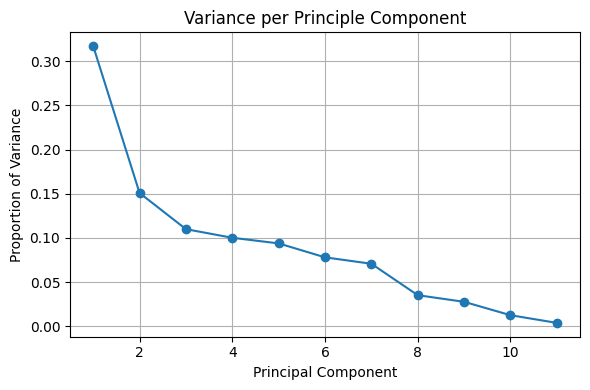

In [ ]:
# 4.2 Principal Component Analysis (PCA)
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

# Fit PCA
X = df[predictor_cols].dropna()
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

pca = PCA()
pca.fit(X_scaled)

# variance ratios and cumulative explained variance
explained_var = pca.explained_variance_ratio_
cum_explained = explained_var.cumsum()

# plot variance per PCA
plt.figure(figsize=(6,4))
plt.plot(range(1, len(explained_var) + 1), explained_var, marker="o")
plt.xlabel("Principal Component")
plt.ylabel("Proportion of Variance")
plt.title("Variance per Principle Component")
plt.grid(True)
plt.tight_layout()
plt.show()


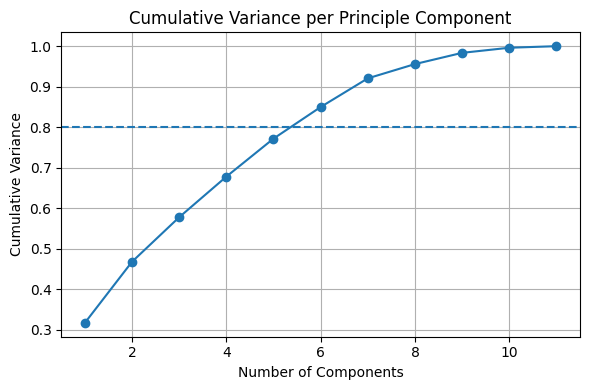

In [ ]:

# plot Cumulative variance per PCA
plt.figure(figsize=(6,4))
plt.plot(range(1, len(cum_explained) + 1), cum_explained, marker="o")
plt.axhline(0.80, linestyle="--")  # 80% reference line
plt.xlabel("Number of Components")
plt.ylabel("Cumulative Variance")
plt.title("Cumulative Variance per Principle Component")
plt.grid(True)
plt.tight_layout()
plt.show()

# reduce data to 2 components for K-means
pca_2 = PCA(n_components=2)
X_pca2 = pca_2.fit_transform(X_scaled)
pca_2_df = pd.DataFrame(X_pca2, columns=["PC1", "PC2"])

In [ ]:
# Display 5 PCA and its feature contribution
n_components_to_show = 5
loadings = pd.DataFrame(
    pca.components_.T[:, :n_components_to_show],   # take only first 5 PCs
    index=predictor_cols,
    columns=[f"PC{i+1}" for i in range(n_components_to_show)]
)
print("\nPCA Loadings (feature contributions to each component):")
display(loadings)


PCA Loadings (feature contributions to each component):


,PC1,PC2,PC3,PC4,PC5
Inflation Rate(in US),0.204450,-0.234474,0.086612,-0.170037,-0.306408
Cash Flow from Operating,0.493861,0.099856,0.006416,-0.019971,0.002765
Cash Flow from Investing,-0.275544,-0.047846,0.365784,-0.508315,0.230094
Cash Flow from Financial Activities,-0.414834,-0.040567,-0.112080,0.461326,-0.193462
Current Ratio,-0.009916,-0.058354,-0.599455,0.266683,0.381673
Debt/Equity Ratio,0.059372,0.135500,0.636358,0.537486,-0.019939
EBITDA,0.507445,0.037998,-0.108212,-0.159047,0.038168
Earning Per Share,0.136050,-0.662144,-0.008781,0.103083,0.057079
Share Holder Equity,0.419708,0.079906,0.054501,0.285302,-0.142772
Free Cash Flow per Share,-0.004156,0.680504,-0.139331,-0.072519,0.004602


####**Interpretation of PCA Results**
The PCA decomposition reveals several important patterns in the financial
predictor space. The scree plot shows a strong drop in variance after the first
two components, with PC1 explaining just above 30% of total variance and PC2
adding roughly another 15%. The cumulative variance curve shows that the first
five components explain approximately 78% of the total variance, and the first
six components exceed the 80% threshold commonly used for dimensionality
reduction. This indicates that the financial structure of the dataset is
effectively captured by a small set of latent dimensions.

The loadings matrix helps interpret what each principal component represents:

- **PC1 (Profitability & Operating Strength)**  
  PC1 is driven heavily by:
  - EBITDA (0.507)  
  - Cash Flow from Operating (0.494)  
  - Share Holder Equity (0.420)  
  These predictors describe earnings quality and operational cash generation.  
  Negative loadings for Cash Flow from Financial Activities (-0.414) indicate a
  contrast between internally generated profits and externally financed activity.

- **PC2 (Shareholder Returns vs. EPS / Cash Flow Mix)**  
  PC2 is dominated by:
  - Free Cash Flow per Share (0.685)  
  - Earning Per Share (-0.662)  
  This suggests PC2 captures a trade-off between cash-flow-based and earnings-based
  shareholder metrics. Industries that emphasize reinvestment vs. payout policies
  will differ strongly along this axis.

- **PC3 (Leverage & Capital Structure)**  
  PC3 shows strong influence from:
  - Debt/Equity Ratio (0.636)  
  - Cash Flow from Investing (0.366)  
  - Return on Tangible Equity (0.218)  
  This suggests that PC3 captures how aggressively firms finance operations and
  invest in long-term assets.

- **PC4 and beyond** contribute smaller, more specific patterns relating to
  balance-sheet structure, liquidity (e.g., Current Ratio), and financing activity.


Overall, PCA reveals three major financial dimensions:

1. **Earnings power and operational profitability** (PC1)  
2. **Differences in shareholder-return strategies** (PC2)  
3. **Capital structure and leverage intensity** (PC3)

These components provide interpretable and compact representations of company
financial behavior and will be used in the clustering analysis in the next
section.



###**4.3 Cluster Analysis**

To complement the regression and PCA results, I applied K-Means clustering to
identify groups of companies with similar financial characteristics. Clustering
helps uncover structural patterns in the data that may not be visible through
individual predictors or linear models alone.

#### **Clustering Methodology**

1. **Standardization:**  
   All financial predictor variables were standardized using z-scores to ensure
   that differences in scale (e.g., cash flow magnitudes vs. ratios) did not distort
   cluster boundaries.

2. **Dimensionality Context from PCA:**  
   Although clustering was performed using all standardized predictors, the first
   two principal components (PC1 and PC2) were used for visualization.  
   These components capture the major financial themes:  
   - PC1: profitability and operating strength  
   - PC2: shareholder return style (cash-flow vs. earnings emphasis)

3. **Choosing the Number of Clusters (k):**  
   Models were tested for **k = 2 through 7**, and metric that guided the selection:
    - We used the elbow method on the K-Means inertia curve and selected k = 3 as the smallest number of clusters beyond which additional clusters gave only marginal improvement, while still yielding interpretable financial groupings (high, moderate, and weak performers).
   
4. **Final Clustering Assignment:**  
   After selecting the optimal k, K-Means was fitted to the standardized predictors
   and each firm-year observation was assigned a cluster label. These clusters were
   then visualized in the PC1–PC2 space to show how financial characteristics
   group firms naturally.


Clusters are compared using average financial metrics to understand the economic
profiles behind each group and to see how these clusters correspond with the
performance outcomes analyzed earlier (ROE, ROA, Net Income, Market Cap).

This unsupervised learning step reveals broader financial patterns that reinforce,
challenge, or contextualize the findings from PCA and regression.


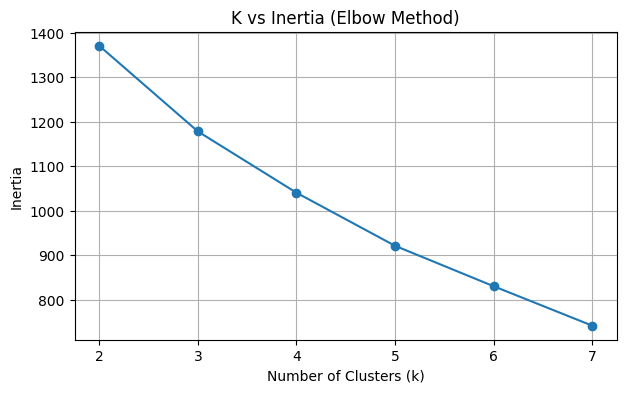

In [ ]:
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
import numpy as np

# Standardize predictors
X = df[predictor_cols].dropna()
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Elbow method: compute inertia for k = 2..7
K_values = range(2, 8)
inertias = []

for k in K_values:
    kmeans = KMeans(n_clusters=k, random_state=1001, n_init=10)
    kmeans.fit(X_scaled)
    inertias.append(kmeans.inertia_)

# Plot K vs Inertia (Elbow Plot)
plt.figure(figsize=(7, 4))
plt.plot(K_values, inertias, marker='o')
plt.title("K vs Inertia (Elbow Method)")
plt.xlabel("Number of Clusters (k)")
plt.ylabel("Inertia")
plt.grid(True)
plt.show()

In [ ]:
# From elbow plot we fix k = 3
optimal_k = 3
print(f"\nChosen number of clusters (k): {optimal_k}")

# Fit final K-Means model with k = 3
kmeans_final = KMeans(n_clusters=optimal_k, random_state=1001, n_init=10)
cluster_labels = kmeans_final.fit_predict(X_scaled)

# Attach cluster labels back to the original rows used in X
df_clusters = df.loc[X.index].copy()
df_clusters["Cluster"] = cluster_labels

print("\nCluster counts:")
display(df_clusters["Cluster"].value_counts())


Chosen number of clusters (k): 3

Cluster counts:


,count
Cluster,
0,134
1,26
2,1


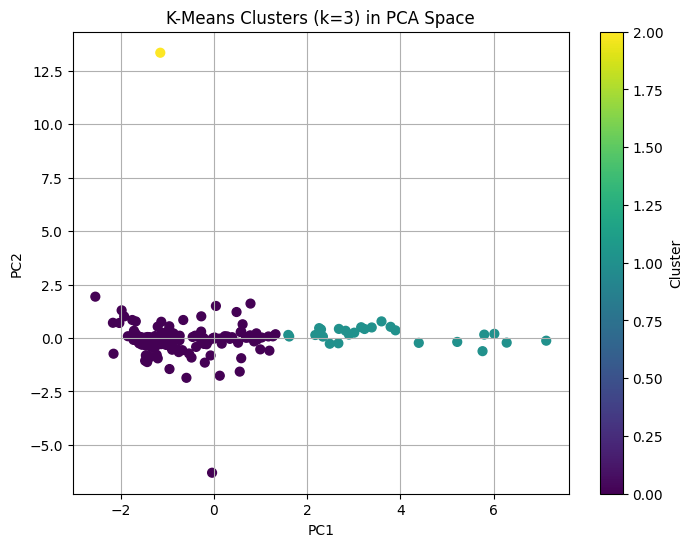

In [ ]:
# PCA to visualize clusters in 2D
pca_2 = PCA(n_components=2)
X_pca2 = pca_2.fit_transform(X_scaled)

plt.figure(figsize=(8, 6))
plt.scatter(X_pca2[:, 0], X_pca2[:, 1],
            c=cluster_labels, cmap="viridis", s=40)
plt.title(f"K-Means Clusters (k={optimal_k}) in PCA Space")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.colorbar(label="Cluster")
plt.grid(True)
plt.show()


In [ ]:
# Cluster profiles for predictors
cluster_profiles = df_clusters.groupby("Cluster")[predictor_cols].mean()
print("\nFinancial Predictor Profiles by Cluster:")
display(cluster_profiles)


Financial Predictor Profiles by Cluster:


,Inflation Rate(in US),Cash Flow from Operating,Cash Flow from Investing,Cash Flow from Financial Activities,Current Ratio,Debt/Equity Ratio,EBITDA,Earning Per Share,Share Holder Equity,Free Cash Flow per Share,Return on Tangible Equity
Cluster,,,,,,,,,,,
0,2.064174,11506.829642,-6477.021272,-2389.652462,2.053698,0.652290,10246.289999,1.137661,41329.834694,-0.855422,19.120656
1,3.192242,68720.846154,-26172.461538,-39811.269231,1.980723,0.591031,71048.076923,3.703000,137284.038462,0.320873,52.139885
2,-0.355500,18584.000000,5778.000000,-28997.000000,1.000000,1.155200,27765.000000,-90.480000,98076.000000,137.328700,-13.950700


In [ ]:
# Cluster profiles for target variables
target_cols = list(best_predictors_for_goals.keys())
target_profiles = df_clusters.groupby("Cluster")[target_cols].mean()

print("\nPerformance Target Averages by Cluster:")
display(target_profiles)


Performance Target Averages by Cluster:


,ROE,ROA,ROI,Net Profit Margin,Net Income,Revenue,Market Cap(in B USD)
Cluster,,,,,,,
0,6.724314,6.399841,9.264012,12.270540,5551.751785,44248.587478,148.786992
1,44.071719,15.253488,26.060919,22.125208,47878.576923,238812.346154,1316.306923
2,-45.306100,-1.512300,-6.064100,-16.228600,-12244.000000,75447.000000,4.040000


###**Clustering Findings**

Using K-Means clustering, we grouped firms into three clusters (k = 3).
The value of k was selected using the elbow method, which showed diminishing
improvements in within-cluster inertia beyond three clusters, while still producing financially interpretable groups.

The clusters reveal three distinct financial profiles among the companies:

#### **Cluster 0 – Strong Profitability & High Performance**
- Very high EBITDA and Operating Cash Flow
- Strong Return on Equity (44%), Return on Assets (15%), and ROI (26%)
- Extremely high Market Cap approximately 1.3T.
- Represents financially dominant firms with exceptional profitability and scale

#### **Cluster 1 – Moderate, Stable Firms**
- Moderate profitability and cash flow levels
- ROE and ROA around 6–7%
- Net Income and Market Cap are much lower than Cluster 0
- Represents financially healthy but not high-performing firms, likely steady mature companies

#### **Cluster 2 – Negative or Weak Performance**
- Low or negative profitability metrics (ROE = –45%, ROI = –6%)
- Negative Net Profit Margin and Net Income
- Higher leverage (Debt/Equity Ratio > 1.1)
- Only one company falls into this cluster, likely an extreme outlier with poor financial structure

#### **Supporting Observations**
- Cluster 0 companies cluster tightly on the positive side of PC1, aligning with high profitability.
- Cluster 1 appears more spread out but generally centered around lower profitability and moderate leverage.
- Cluster 2 appears isolated in PCA space due to its extreme financial behavior.
- The features that most strongly differentiate clusters are EBITDA, Operating Cash Flow, Debt/Equity Ratio, and Net Income.

#### **Interpretation**
These clusters reinforce earlier PCA and regression findings:
- Profitability-driven variables (EBITDA, Operating Cash Flow) strongly shape firm behavior.
- Large, high-performing firms form a distinct group.
- Most companies fall into a moderate-performance cluster.
- A very small number of firms exhibit extreme underperformance.

Clustering provides a clear segmentation of companies based on their financial structure and supports the overall narrative that earnings power and cash generation are the main drivers of firm differentiation in this dataset.


# **Section 5: Discussion**

## **Implications**

- Earnings and cash-flow measures (EBITDA, Operating Cash Flow, EPS) consistently dominate model performance, making them the strongest indicators of firm profitability and valuation.  
- Liquidity and leverage ratios (Current Ratio, Debt/Equity) are more informative for ROA and ROE, reflecting their role in operational efficiency and capital structure.  
- PCA shows that most firm-level variation is explained by a small number of latent dimensions centered on profitability, financing structure, and earnings power.  
- K-Means clustering separates firms into high-performing, moderate, and underperforming groups with clearly interpretable financial profiles.  
- Scale-driven outcomes (Revenue, Net Income, Market Cap) achieve high predictive accuracy, indicating the dataset captures core valuation drivers.  
- Overall, the results help analysts prioritize financial metrics that provide the greatest explanatory value for performance evaluation and peer comparison.

## **Limitations**

- The analysis is limited to large, established firms, reducing generalizability to small or high-growth companies.  
- Data coercion and missing values may weaken certain regression results, particularly for ROI.  
- Companies fucntion under different financial strucutres, pooling them together in one model can blue or show bias relationship.
- Linear regression assumptions may be violated due to strong multicollinearity among financial variables.  
- PCA’s linear structure may oversimplify complex financial relationships.  
- Data set does not include investory sentiment, which can heavily influeance valuation of a company.
- Economic shocks between 2009–2023 introduce time-based effects not modeled explicitly.



# **SECTION 6 — Conclusion**

This project evaluated whether financial statement variables can reliably predict key performance metrics for major U.S. and global companies from 2009–2023. Through multivariate regression, PCA, and clustering, we identified which predictors consistently carry the strongest explanatory value for ROE, ROA, ROI, Net Profit Margin, Net Income, Revenue, and Market Cap.

Across nearly all targets, **profitability and cash-flow metrics**—particularly EBITDA, Operating Cash Flow, and Earnings Per Share—emerged as the most influential predictors. PCA further showed that most variation in firm financial structure can be summarized by a few dominant components related to earnings strength, leverage, and capital flows, supporting more efficient modeling.

Clustering analysis revealed three natural groups of firms (high-performing, moderate, and underperforming), each with distinct financial profiles and outcome patterns, reinforcing the interpretability of the derived predictors.

Overall, the results demonstrate that traditional financial indicators still retain strong predictive value and that combining regression, dimensionality reduction, and clustering provides a deeper understanding of corporate performance. While some metrics like ROI remain difficult to predict, the integrated approach offers a robust framework for analyzing firm fundamentals and comparing companies across industries.
